# An Intuition Builder for Regression Diagnostic Plots

Fitting a regression model is easy. Knowing whether you can *trust* it is the harder skill.

Diagnostic plots are some of the best and most widely accepted tools to build this trust. However, over the years I have noticed that instructors often gloss over these plots, as if the audience has the same intuitive understanding they do.

I developed this notebook to walk you through the plots while allowing you to interact with them, so that ***YOU* build the intuition!**

This notebook covers the **standard four-panel diagnostic set** (the same four plots R produces by
default from `plot(lm_model)`), plus a fifth check for the independence assumption that the standard
panel doesn't address:

1. **Residuals vs. Fitted** - checks linearity and homoscedasticity (constant variance)
2. **Q-Q Plot** - checks normality of residuals
3. **Scale-Location** - a dedicated, more sensitive view of homoscedasticity
4. **Residuals vs. Leverage (with Cook's distance)** - finds influential observations
5. **Residuals vs. order / ACF** - checks independence (relevant for ordered or time-series data)

For each one, we show what an **ideal** plot looks like next to plots showing **specific problems**,
so the shapes become recognizable at a glance rather than something you have to consciously reason
through every time.

**A note on what these plots do and don't tell you:** the first three check *model assumptions*.
The fourth plot is different, as it checks whether any individual data point is disproportionately
influencing your results. Both matter, but they're distinct questions, and conflating them is a
common source of confusion.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

## 1. Residuals vs. Fitted Values

After fitting a model, plot the **residuals** (actual - predicted) on the y-axis against the
**fitted values** (predicted values) on the x-axis.

**What you're looking for:** a random, formless scatter of points around the horizontal line at
zero, with no pattern in the spread and no curve. If you see structure, that structure is telling
you something specific about which assumption is broken.

We'll simulate three datasets below: one that satisfies OLS assumptions cleanly, one with
**heteroscedasticity** (non-constant variance), and one with **non-linearity** (wrong functional
form). Same sample size and base noise scale throughout, so the *shape* of the residual plot is the
only thing that differs.


In [37]:
def fit_model(X, y):
    """Fit OLS and return the fitted model object."""
    X_with_const = sm.add_constant(X)
    return sm.OLS(y, X_with_const).fit()

n = 200
x = np.linspace(0, 10, n)

# Case 1: Ideal Example
y_ideal = 3 + 2 * x + np.random.normal(0, 3, n)
model_ideal = fit_model(x, y_ideal)

# Case 2: Heteroscedasticity (variance grows with x)
y_hetero = 3 + 2 * x + np.random.normal(0, 0.3 + 0.35 * x, n)
model_hetero = fit_model(x, y_hetero)

# Case 3: Non-linearity (true relationship is quadratic, model is linear)
y_nonlin = 3 + 1.2 * x + .9 * (x - 5) ** 2 + np.random.normal(0, 3, n)
model_nonlin = fit_model(x, y_nonlin)

Before we look at the residual plots, let's first build a foundation by understanding where they come from.

We will do so by observing a more familiar plot: predicted versus actuals plots.

Below we have predicted versus actuals plots for each of the three simulated datasets: the ideal linear set, the heteroscedastic set, and the non-linear set.

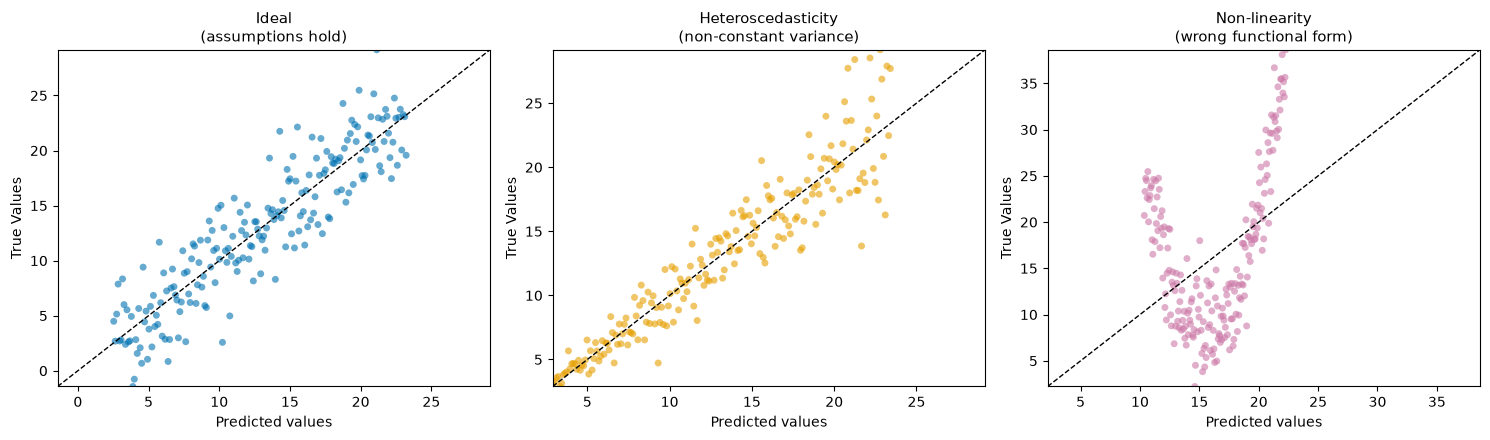

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels_1 = [
    (axes[0], model_ideal, y_ideal, "Ideal\n(assumptions hold)", "#0072B2"),
    (axes[1], model_hetero, y_hetero, "Heteroscedasticity\n(non-constant variance)", "#E69F00"),
    (axes[2], model_nonlin, y_nonlin, "Non-linearity\n(wrong functional form)", "#CC79A7"),
]

for ax, model, y_true, title, color in panels_1:
    ax.scatter(model.fittedvalues, y_true, alpha=0.6, s=25, color=color, edgecolor="none")
    lims = [min(model.fittedvalues.min(), y_true.min()),max(model.fittedvalues.max(), y_true.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("Predicted values")
    ax.set_ylabel("True Values")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

- In the **ideal** panel, points hug the diagonal with no systematic drift.
- In the **heteroscedastic** panel, points sit close to the diagonal at low predicted values but scatter further from it as predicted values grow. 
- In the **non-linear** panel, points bow away from the diagonal in the middle of the range and pull back toward it at the edges.

Each point's vertical distance from the dashed diagonal above is exactly its residual (how far the actual value sits from the predicted value). 

Below, we plot that distance directly: the horizontal axis stays the same (still fitted values), but the vertical axis now shows actual minus predicted instead of actual. The diagonal collapses into a flat line at zero, and everything else about each point's position carries over.

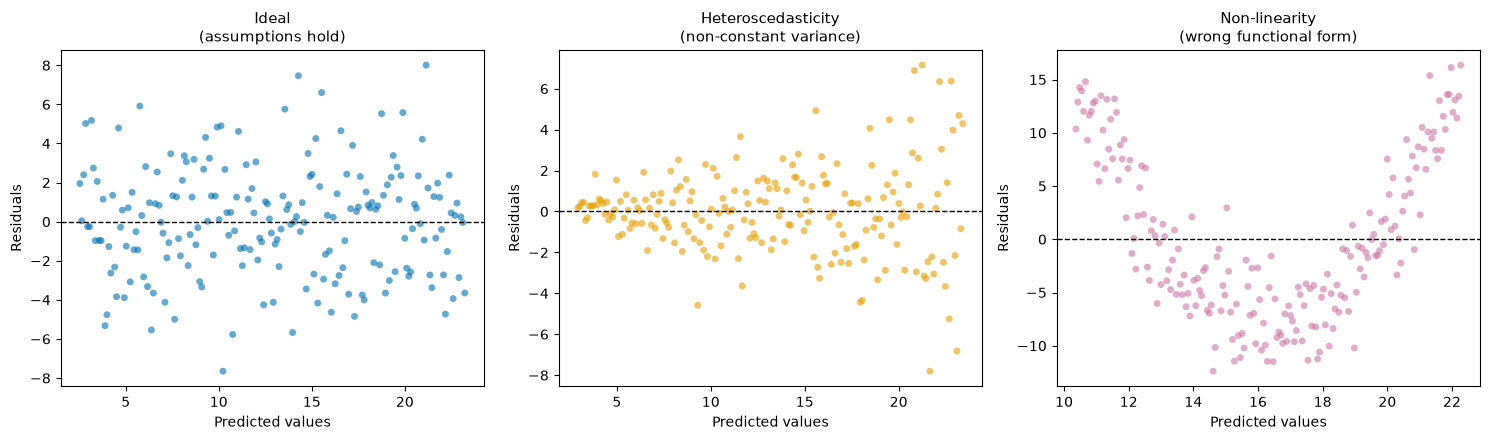

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

panels = [
    (axes[0], model_ideal, "Ideal\n(assumptions hold)", "#0072B2"),
    (axes[1], model_hetero, "Heteroscedasticity\n(non-constant variance)", "#E69F00"),
    (axes[2], model_nonlin, "Non-linearity\n(wrong functional form)", "#CC79A7"),
]

for ax, model, title, color in panels:
    ax.scatter(model.fittedvalues, model.resid, alpha=0.6, s=25, color=color, edgecolor="none")
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Residuals")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()


**Reading each panel:**

- **Ideal:** points scatter randomly above and below the zero line, with no widening and no curve. Homoscedasticity and linearity both hold.

- **Heteroscedasticity:** the *shape* is a fan. Residuals stay tight near low fitted values and spread out wider as fitted values increase. The mean of the residuals is still roughly zero everywhere (so it's *not* a linearity problem), but the **spread is not constant**, and that's the giveaway. 
Practical consequence: your standard errors (and therefore p-values and confidence intervals) become unreliable, even though the coefficient estimates themselves stay unbiased.

- **Non-linearity:** the residuals trace a visible **curve**, negative at the edges and positive in the middle (or vice versa). This means the model is systematically over- or under-predicting depending on where you are in the range of x, because the true relationship isn't a straight line. Fix: add a polynomial term, transform a variable, or reconsider the functional form.

**The distinction worth internalizing:** both patterns show up in the *same type* of plot, so it's easy to collapse "there's some pattern here" into one generic red flag. They're not the same problem, and they don't have the same fix. 

Remember:
- Heteroscedasticity is about the **spread and width** changing.
- Non-linearity is about the **center** of the residuals tracing a shape instead of sitting flat at zero.

## 2. Q-Q Plot (Normality Check)

The next assumption we need to check is **whether the residuals are normally distributed**. 

This is a genuinely
different question from the last section. Linearity and constant variance are about *where*
residuals sit and *how wide* they spread as fitted values change. Normality is about the *shape of
their distribution*, ignoring fitted values entirely.

The **Q-Q plot** is the standard tool for this, and I also found it the least intuitive plot in the
diagnostic set. So rather than open with it, we'll build up to it in three views, each one a
sharper look at the same question: *do these residuals look like they came from a normal
distribution?*

We'll carry three sets of residuals through all three views:

- **Normal** - genuinely drawn from a normal distribution
- **Right-skewed** - common with count data, spend data, or anything bounded at zero
- **Heavy-tailed** - the bulk looks normal, but extreme values show up far more often than they should

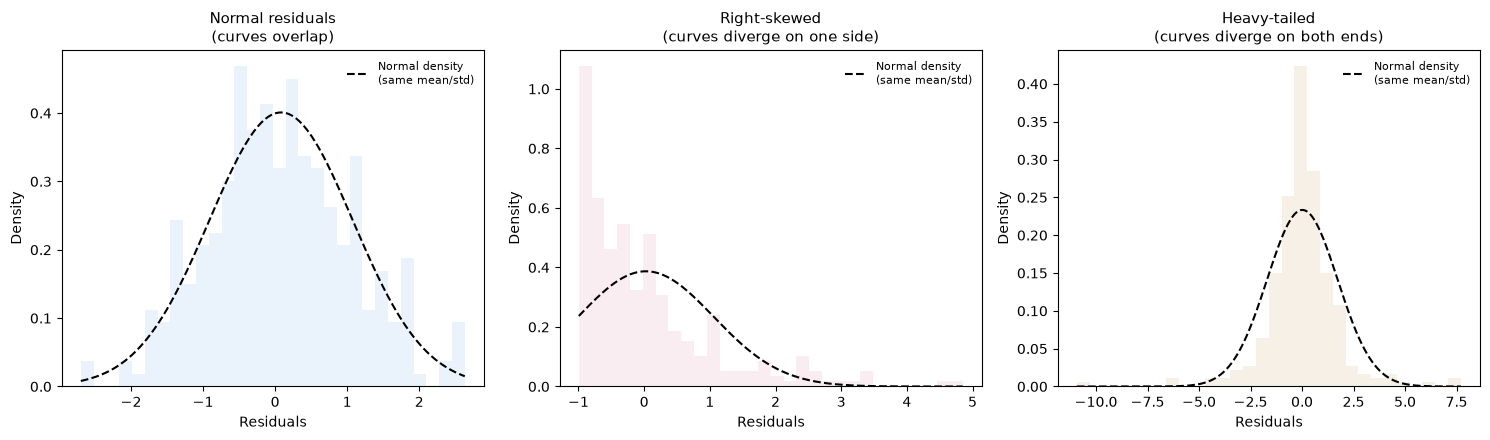

In [40]:
resid_normal = np.random.normal(0, 1, 300)
resid_skewed = np.random.exponential(1, 300) - 1
resid_heavy = stats.t.rvs(df=3, size=300)

specs = [
    (resid_normal, "Normal residuals\n(curves overlap)", "#378ADD"),
    (resid_skewed, "Right-skewed\n(curves diverge on one side)", "#D4537E"),
    (resid_heavy, "Heavy-tailed\n(curves diverge on both ends)", "#BA7517"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (resid, title, color) in zip(axes, specs):
    ax.hist(resid, bins=30, density=True, color=color, alpha=0.1, edgecolor="none")

    mu, sigma = np.mean(resid), np.std(resid)
    xs = np.linspace(resid.min(), resid.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, loc=mu, scale=sigma), color="black",
            linewidth=1.5, linestyle="--", label="Normal density\n(same mean/std)")

    ax.set_xlabel("Residuals")
    ax.set_ylabel("Density")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

Notice the heavy-tailed histogram (right) looks nearly indistinguishable from normal (left) here. That's not a coincidence, it's exactly the failure mode a histogram has: outliers are rare enough that they don't visually register as a different shape. That's the whole reason Q-Q plots exist, they make exactly this kind of subtle tail deviation visible instead of hiding it in a handful of thin bars.

A histogram checks the shape at a glance, but it treats individual points as disposable once they're grouped into bins. The next view holds every point accountable instead. We'll sort the residuals from smallest to largest and compare them, one rank at a time, against what a normal distribution would produce at that same rank. The rare extreme points a histogram can hide inside a thin bar will show up here as a visible gap between two lines.

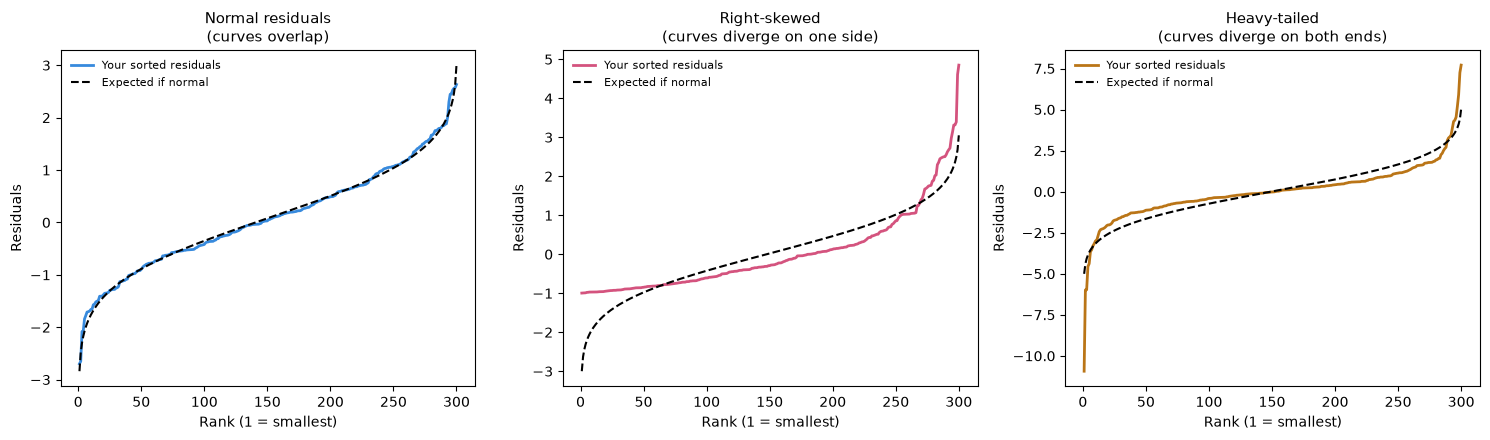

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (resid, title, color) in zip(axes, specs):
    n = len(resid)
    ranks = np.arange(1, n + 1)
    sorted_resid = np.sort(resid)

    # Standard plotting-position formula, same convention statsmodels uses internally
    probs = (ranks - 0.5) / n
    theoretical = stats.norm.ppf(probs, loc=np.mean(resid), scale=np.std(resid))

    ax.plot(ranks, sorted_resid, color=color, linewidth=2, label="Your sorted residuals")
    ax.plot(ranks, theoretical, color="black", linewidth=1.5, linestyle="--", label="Expected if normal")
    ax.set_xlabel("Rank (1 = smallest)")
    ax.set_ylabel("Residuals")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

Right-skewed residuals are easy to catch this way. The spike near zero and the long thin tail stretching right are visible from across the room. Heavy-tailed residuals are the tricky case. The bars still trace something close to a bell shape, since only a handful of extreme points sit out past the edges, and a histogram bins and counts, so those rare points barely dent the overall shape. That's the blind spot worth remembering: a distribution can look normal in a histogram while still failing normality in ways that matter for inference.

Both plots above show the exact same two sequences: your sorted residuals, and what a normal distribution would produce at each matching rank. Rank was doing the pairing between them. If we drop rank as its own axis and instead plot one sequence directly against the other, pairing each residual with its normal counterpart at that same rank, we get a Q-Q plot. Same information, one less axis.

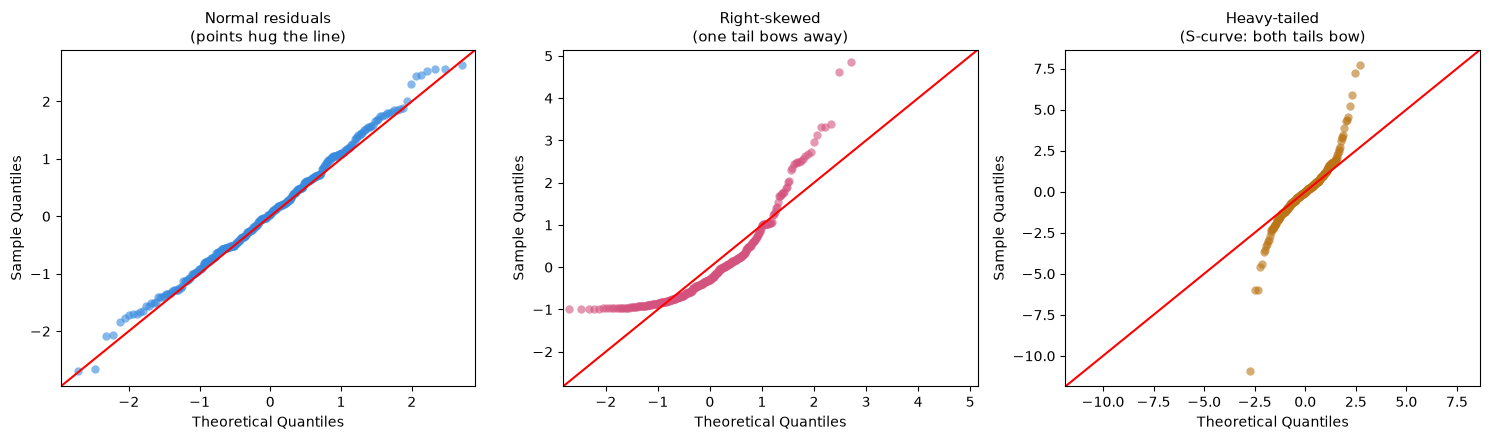

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

specs = [
    (axes[0], resid_normal, "Normal residuals\n(points hug the line)", "#378ADD"),
    (axes[1], resid_skewed, "Right-skewed\n(one tail bows away)", "#D4537E"),
    (axes[2], resid_heavy, "Heavy-tailed\n(S-curve: both tails bow)", "#BA7517"),
]

for ax, resid, title, color in specs:
    sm.qqplot(resid, line="45", ax=ax, markerfacecolor=color,
              markeredgecolor="none", alpha=0.6)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

The red line marks where a point would land if your residual exactly matched its expected value under normality, the same role the dashed line played above, just rotated into a direct comparison instead of a shared-rank overlay. Normal residuals sit almost on top of it end to end. Right-skewed residuals track the line through the lower and middle ranks, then peel sharply upward at the high end, a handful of points at the top climbing far faster than a normal distribution would predict, the one-sided pull you already saw in the rank plot, now visible as points lifting off the line rather than two curves drifting apart. Heavy-tailed residuals show the S-curve: points dip below the line at the low end and rise above it at the high end, both tails pulling away symmetrically while the middle ranks still sit close to the line.

## 3. Scale-Location Plot
placeholder

## 4. Residuals vs. Leverage (and Cook's Distance)
placeholder

## 5. Independence: Residuals vs. Order (and the ACF)
placeholder